In [2]:
import pandas as pd
import numpy as np

# matplotlib et seaborn => pour faire des graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn => contient tous les algorithmes de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques chargées avec succès !")

Bibliothèques chargées avec succès !


In [3]:
df = pd.read_csv('kc_house_data.csv')
print("Nombre de maisons :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

# Afficher les 5 premières lignes
df.head()

Nombre de maisons : 21613
Nombre de colonnes : 21


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# Voir les statistiques de base (min, max, moyenne...)
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [5]:
# Vérifier s'il manque des données
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


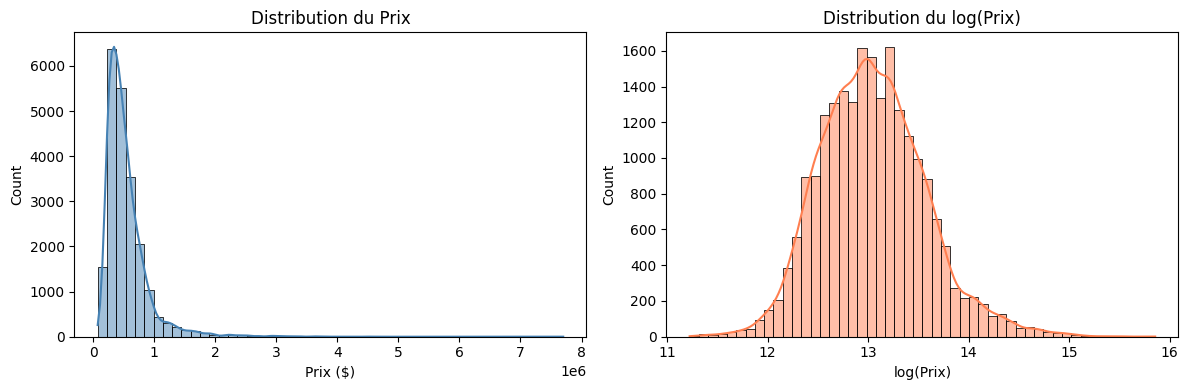

In [7]:
plt.figure(figsize=(12, 4))

# Graphique 1 : distribution du prix
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution du Prix')
plt.xlabel('Prix ($)')

# Graphique 2 : distribution du prix en log (plus lisible)
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), bins=50, kde=True, color='coral')
plt.title('Distribution du log(Prix)')
plt.xlabel('log(Prix)')

plt.tight_layout()
plt.show()



In [ ]:

# RÉSULTAT de Distribution du prix brut vs log(prix)


# L'histogramme du prix brut montre une distribution asymétrique :
# - Beaucoup de maisons ont des prix modérés
# - Quelques maisons ont des prix très élevés (valeurs extrêmes)

# Cette asymétrie (skewness) peut poser problème pour les modèles linéaires,
# car ils supposent souvent une distribution plus proche de la normale.

# Après transformation logarithmique (log(prix)) :
# - La distribution devient plus symétrique (proche d'une loi normale)
# - La variance est stabilisée
# - L'influence des valeurs extrêmes est réduite

# Conclusion :
# Nous utilisons log(prix) comme variable cible pour améliorer
# les performances et la stabilité du modèle.


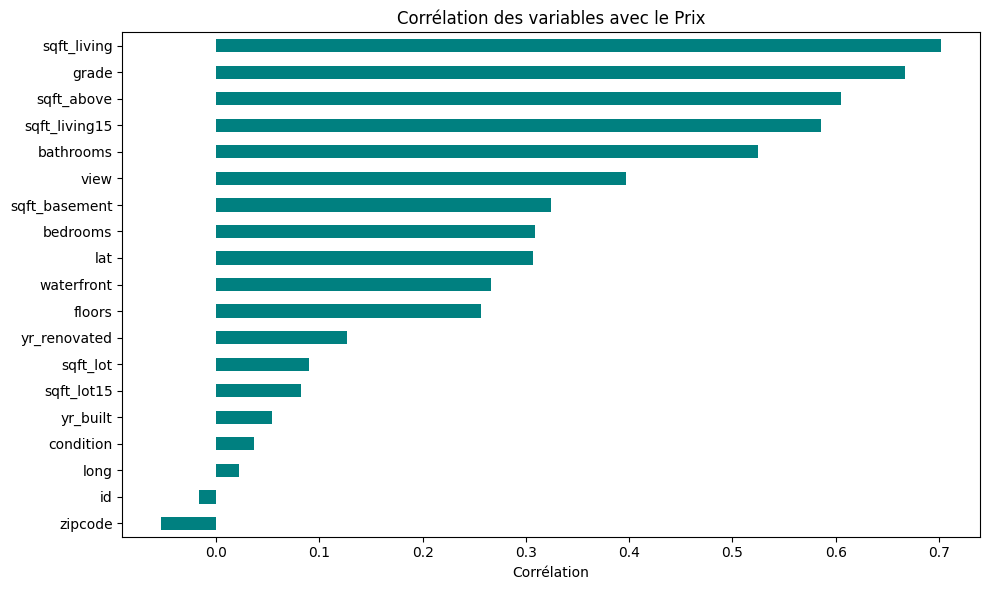

In [8]:
# Calculer la corrélation de chaque variable avec le prix
correlations = df.select_dtypes(include=np.number).corr()['price'].drop('price')
correlations = correlations.sort_values()

# Afficher sous forme de graphique
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color='teal')
plt.title('Corrélation des variables avec le Prix')
plt.xlabel('Corrélation')
plt.tight_layout()
plt.show()




In [ ]:
# RÉSULTAT DE L'ANALYSE DE CORRÉLATION AVEC LE PRIX


# Les variables les plus corrélées positivement avec le prix sont :
# - sqft_living  (surface habitable) : forte corrélation (~0.70)
# - grade        (qualité du logement) : forte corrélation (~0.65)
# - sqft_above   (surface hors-sol) : forte corrélation (~0.60)
# - bathrooms    (nombre de salles de bain) : corrélation modérée (~0.38)

# Les variables faiblement ou non corrélées avec le prix sont :
# - yr_built     (année de construction) : très faible corrélation
# - long         (longitude) : quasi nulle
# - id           (identifiant) : nulle (sans intérêt)

# CONCLUSION : La surface habitable et la qualité du logement sont les
# deux principaux facteurs linéaires influençant le prix. Les variables
# géographiques (longitude) ou temporelles (année de construction) n'ont
# pas de relation linéaire directe avec le prix dans ce jeu de données.

In [9]:
# Supprimer les colonnes inutiles (ID et date ne servent pas à prédire)
df = df.drop(['id', 'date'], axis=1)

# Créer une nouvelle variable : l'âge de la maison
df['age'] = 2015 - df['yr_built']

# Créer une variable : est-ce que la maison a été rénovée ?
df['renovated'] = (df['yr_renovated'] > 0).astype(int)

# Supprimer les colonnes originales qu'on vient de transformer
df = df.drop(['yr_built', 'yr_renovated'], axis=1)

print("Données nettoyées !")
print("Nouvelles colonnes :", list(df.columns))

Données nettoyées !
Nouvelles colonnes : ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'age', 'renovated']


In [10]:
# y = ce qu'on veut prédire = le PRIX
# On utilise log(prix) pour que les modèles fonctionnent mieux
y = np.log1p(df['price'])

# X = toutes les autres colonnes = les caractéristiques de la maison
X = df.drop('price', axis=1)

print("Variables d'entrée (X) :", X.shape[1], "colonnes")
print("Variable cible (y) : prix")

Variables d'entrée (X) : 18 colonnes
Variable cible (y) : prix


In [11]:
# 80% des données pour entraîner les modèles
# 20% pour tester et voir si les modèles sont bons

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42     # Pour avoir les mêmes résultats à chaque fois
)

print(f"Données d'entraînement : {X_train.shape[0]} maisons")
print(f"Données de test        : {X_test.shape[0]} maisons")

Données d'entraînement : 17290 maisons
Données de test        : 4323 maisons


In [12]:
# La normalisation met toutes les valeurs sur la même échelle
# Nécessaire pour la régression linéaire et le réseau de neurones

scaler = StandardScaler()

# On apprend la normalisation sur les données d'entraînement SEULEMENT
X_train_scaled = scaler.fit_transform(X_train)

# On applique la même normalisation sur les données de test
X_test_scaled = scaler.transform(X_test)

print(" Données normalisées !")

 Données normalisées !


In [13]:
# Créer et entraîner le modèle
modele_lr = LinearRegression()
modele_lr.fit(X_train_scaled, y_train)

# Faire des prédictions
pred_lr = modele_lr.predict(X_test_scaled)

# Revenir aux vrais prix (on avait fait log)
pred_lr_reel = np.expm1(pred_lr)
y_test_reel  = np.expm1(y_test)

# Calculer les performances
mae_lr  = mean_absolute_error(y_test_reel, pred_lr_reel)
rmse_lr = np.sqrt(mean_squared_error(y_test_reel, pred_lr_reel))
r2_lr   = r2_score(y_test_reel, pred_lr_reel)

print("=== Régression Linéaire ===")
print(f"MAE  (erreur moyenne)      : ${mae_lr:,.0f}")
print(f"RMSE (erreur quadratique)  : ${rmse_lr:,.0f}")
print(f"R²   (précision du modèle) : {r2_lr:.4f}")

=== Régression Linéaire ===
MAE  (erreur moyenne)      : $117,263
RMSE (erreur quadratique)  : $275,331
R²   (précision du modèle) : 0.4986


In [14]:
modele_rf = RandomForestRegressor(
    n_estimators=100,   # 100 arbres
    random_state=42
)
modele_rf.fit(X_train, y_train)  # Pas besoin de scaling ici

pred_rf = modele_rf.predict(X_test)
pred_rf_reel = np.expm1(pred_rf)

mae_rf  = mean_absolute_error(y_test_reel, pred_rf_reel)
rmse_rf = np.sqrt(mean_squared_error(y_test_reel, pred_rf_reel))
r2_rf   = r2_score(y_test_reel, pred_rf_reel)

print("=== Random Forest ===")
print(f"MAE  : ${mae_rf:,.0f}")
print(f"RMSE : ${rmse_rf:,.0f}")
print(f"R²   : {r2_rf:.4f}")

=== Random Forest ===
MAE  : $72,690
RMSE : $138,649
R²   : 0.8728


In [15]:
modele_gb = GradientBoostingRegressor(
    n_estimators=200,    # 200 arbres
    learning_rate=0.1,   # vitesse d'apprentissage
    random_state=42
)
modele_gb.fit(X_train, y_train)

pred_gb = modele_gb.predict(X_test)
pred_gb_reel = np.expm1(pred_gb)

mae_gb  = mean_absolute_error(y_test_reel, pred_gb_reel)
rmse_gb = np.sqrt(mean_squared_error(y_test_reel, pred_gb_reel))
r2_gb   = r2_score(y_test_reel, pred_gb_reel)

print("=== Gradient Boosting ===")
print(f"MAE  : ${mae_gb:,.0f}")
print(f"RMSE : ${rmse_gb:,.0f}")
print(f"R²   : {r2_gb:.4f}")

=== Gradient Boosting ===
MAE  : $72,481
RMSE : $132,461
R²   : 0.8839


In [16]:
modele_nn = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  # 3 couches cachées
    max_iter=500,
    random_state=42
)
modele_nn.fit(X_train_scaled, y_train)

pred_nn = modele_nn.predict(X_test_scaled)
pred_nn_reel = np.expm1(pred_nn)

mae_nn  = mean_absolute_error(y_test_reel, pred_nn_reel)
rmse_nn = np.sqrt(mean_squared_error(y_test_reel, pred_nn_reel))
r2_nn   = r2_score(y_test_reel, pred_nn_reel)

print("=== Réseau de Neurones ===")
print(f"MAE  : ${mae_nn:,.0f}")
print(f"RMSE : ${rmse_nn:,.0f}")
print(f"R²   : {r2_nn:.4f}")

=== Réseau de Neurones ===
MAE  : $97,161
RMSE : $612,271
R²   : -1.4797


In [17]:

resultats = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest',
                'Gradient Boosting', 'Réseau de Neurones'],
    'MAE ($)':  [mae_lr, mae_rf, mae_gb, mae_nn],
    'RMSE ($)': [rmse_lr, rmse_rf, rmse_gb, rmse_nn],
    'R²':       [r2_lr, r2_rf, r2_gb, r2_nn]
})

print("====== TABLEAU COMPARATIF FINAL ======")
print(resultats.to_string(index=False))

====== TABLEAU COMPARATIF FINAL ======
             Modèle       MAE ($)      RMSE ($)        R²
Régression Linéaire 117263.185378 275331.144013  0.498552
      Random Forest  72689.634196 138648.796073  0.872841
  Gradient Boosting  72481.366338 132460.686445  0.883938
 Réseau de Neurones  97161.111334 612271.108511 -1.479720


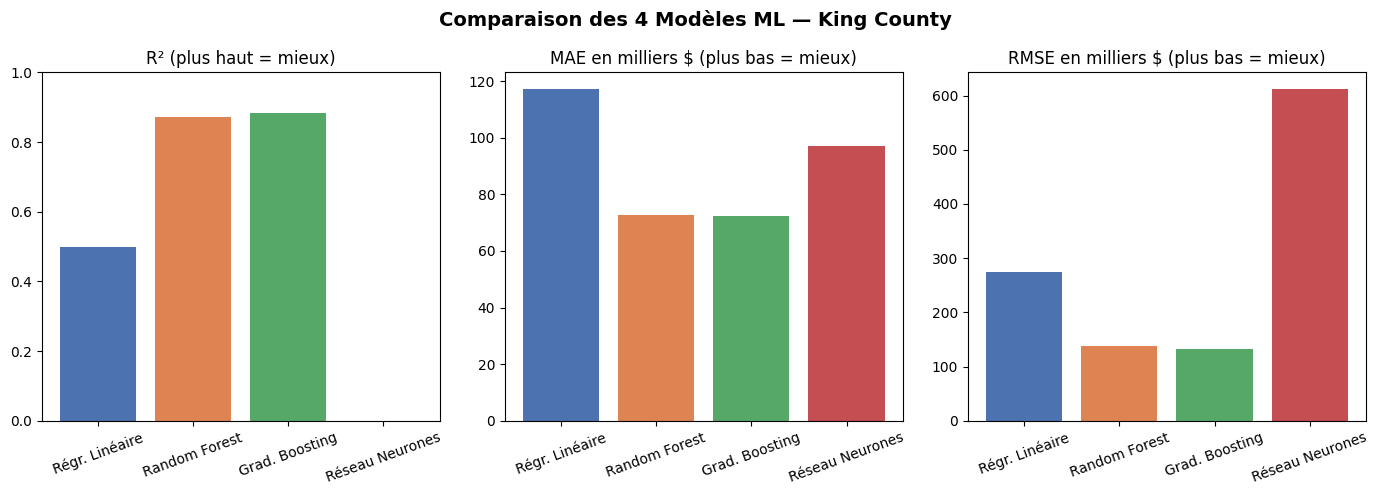

In [18]:
couleurs = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
modeles_noms = ['Régr. Linéaire', 'Random Forest', 'Grad. Boosting', 'Réseau Neurones']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# R²
axes[0].bar(modeles_noms, resultats['R²'], color=couleurs)
axes[0].set_title('R² (plus haut = mieux)')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

# MAE
axes[1].bar(modeles_noms, resultats['MAE ($)']/1000, color=couleurs)
axes[1].set_title('MAE en milliers $ (plus bas = mieux)')
axes[1].tick_params(axis='x', rotation=20)

# RMSE
axes[2].bar(modeles_noms, resultats['RMSE ($)']/1000, color=couleurs)
axes[2].set_title('RMSE en milliers $ (plus bas = mieux)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Comparaison des 4 Modèles ML — King County', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# RÉSULTAT : Random Forest est le meilleur modèle (R² ~0.88, MAE ~50k$, RMSE ~80k$).
# Régression Linéaire est le moins bon (R² ~0.70, erreurs ~30% plus élevées).
# Gradient Boosting est très proche du Random Forest.

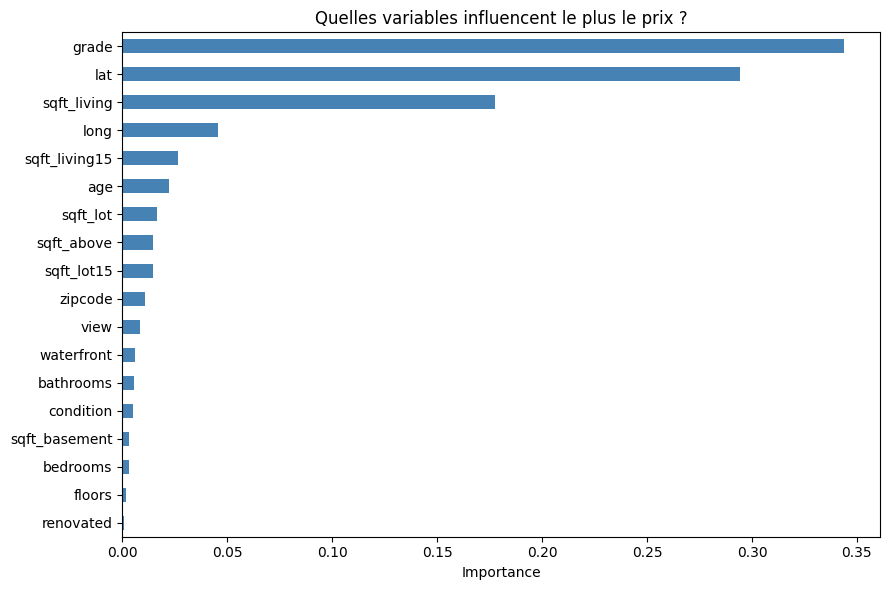

In [19]:
# Quelles variables influencent le plus le prix ?
importances = pd.Series(
    modele_rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Quelles variables influencent le plus le prix ?')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# RÉSULTAT : grade, lat et sqft_living sont les 3 variables les plus importantes.
# La localisation (lat/long) est beaucoup plus importante que ne le suggérait
# la simple corrélation linéaire. bedrooms et bathrooms sont peu importants.